# 阶段一：DQN 训练五子棋 Agent

## 学习目标

| RL 概念 | 本 notebook 的体现 |
|---|---|
| Q 值 | `Q(s, a)` = 从状态 s 执行动作 a 后的期望累计奖励 |
| Bellman 方程 | `Q(s,a) ← r + γ·max Q(s',a')` |
| ε-greedy | 探索（随机）vs 利用（最优 Q 值）的平衡 |
| Experience Replay | 存 transitions，随机采样打破时序相关性 |
| Target Network | 稳定训练目标，防止 Q 值震荡 |

## 为什么用 DQN 而不是表格 Q-Learning？

15×15 五子棋的状态数约 3²²⁵ ≈ 10¹⁰⁷，Q 表根本存不下。  
用神经网络拟合 Q 函数：输入棋盘 state，输出每个 action 的 Q 值。

## 训练策略

先用 **5×5 小棋盘（3连赢）** 快速验证整个流程，  
确认 Agent 能学到比随机策略更好的表现后，可选扩展到更大棋盘。

## Cell 1：导入依赖

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque
import random
import time
from typing import Tuple

print(f"PyTorch 版本: {torch.__version__}")
print(f"MPS 可用: {torch.backends.mps.is_available()}")
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"使用设备: {DEVICE}")

PyTorch 版本: 2.10.0
MPS 可用: True
使用设备: mps


## Cell 2：GomokuEnv（参数化版）

从 01 notebook 的 `GomokuEnv` 提取，增加 `board_size` / `win_count` 参数，  
其余接口（reset / step / get_legal_actions）完全一致。

In [9]:
class GomokuEnv:
    """
    参数化五子棋环境。
    board_size=5, win_count=3 → 5×5 棋盘，3连赢（用于快速验证）
    board_size=15, win_count=5 → 标准五子棋
    """

    def __init__(self, board_size: int = 5, win_count: int = 3):
        self.BOARD_SIZE = board_size
        self.WIN_COUNT  = win_count
        self.board: np.ndarray = None
        self.current_player: int = None
        self.done: bool = None
        self.move_count: int = None
        self.reset()

    def reset(self) -> np.ndarray:
        self.board = np.zeros((self.BOARD_SIZE, self.BOARD_SIZE), dtype=np.int8)
        self.current_player = 1
        self.done = False
        self.move_count = 0
        return self.board.copy()

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, dict]:
        assert not self.done, "Episode 已结束，请先 reset()"
        row, col = divmod(action, self.BOARD_SIZE)

        if self.board[row, col] != 0:
            return self.board.copy(), -1.0, True, {'winner': -self.current_player, 'invalid': True}

        self.board[row, col] = self.current_player
        self.move_count += 1

        if self._check_win(row, col):
            self.done = True
            return self.board.copy(), 1.0, True, {'winner': self.current_player, 'invalid': False}

        if self.move_count == self.BOARD_SIZE ** 2:
            self.done = True
            return self.board.copy(), 0.0, True, {'winner': 0, 'invalid': False}

        self.current_player = -self.current_player
        return self.board.copy(), 0.0, False, {'winner': None, 'invalid': False}

    def get_legal_actions(self) -> np.ndarray:
        return np.where(self.board.flatten() == 0)[0]

    def _check_win(self, row: int, col: int) -> bool:
        player = self.board[row, col]
        for dr, dc in [(0,1),(1,0),(1,1),(1,-1)]:
            count = 1
            for sign in (1, -1):
                r, c = row + sign*dr, col + sign*dc
                while 0 <= r < self.BOARD_SIZE and 0 <= c < self.BOARD_SIZE and self.board[r,c] == player:
                    count += 1
                    r += sign*dr; c += sign*dc
            if count >= self.WIN_COUNT:
                return True
        return False


# 快速验证
env = GomokuEnv(board_size=5, win_count=3)
print(f"5×5 棋盘，动作空间: {env.BOARD_SIZE**2}")
print(f"合法动作数: {len(env.get_legal_actions())}  (应为 25)")

5×5 棋盘，动作空间: 25
合法动作数: 25  (应为 25)


## Cell 3：Q 网络 + 棋盘编码

---

### `board_to_tensor`：棋盘 → 网络输入

棋盘原始值用 `1`/`-1` 区分黑白，但网络需要知道「谁是我」。
双通道把这个信息显式拆开：

- **Channel 0**：我方棋子位置（`board == current_player`）
- **Channel 1**：对方棋子位置（`board == -current_player`）

这样网络永远从「当前落子方」视角看棋盘，黑白双方共用同一个网络不会混乱。

**具体示例**（黑棋在 (1,1)，白棋在 (2,3)，轮黑棋落子）：

```
ch0（我方）:          ch1（对方）:
0 0 0 0 0            0 0 0 0 0
0 1 0 0 0            0 0 0 0 0
0 0 0 0 0            0 0 0 1 0
0 0 0 0 0            0 0 0 0 0
0 0 0 0 0            0 0 0 0 0
```

**`np.stack([ch0, ch1])` → shape `(2, 5, 5)`**：把两张地图叠在一起。

**`.unsqueeze(0)` → shape `(1, 2, 5, 5)`**：在最前面插入 batch 维度。
PyTorch 的 Conv2d 要求输入格式必须是 `(batch, channels, H, W)`，
推理单局面时 batch=1，训练时 batch=64，格式必须一致。

---

### `QNetwork`：网络结构

**命名约定：**
- `conv` = convolution（卷积）的缩写，处理有空间结构的数据
- `fc` = fully connected（全连接）的缩写，也叫 Linear 或 Dense

`self.conv` / `self.fc` 都是 `QNetwork.__init__` 里自定义的属性，名字随意，
但因为赋值的是 `nn.Sequential`（也是 `nn.Module`），PyTorch 会自动把它们
注册为子模块，参数纳入统一管理，`net.parameters()` 能一次性找到所有参数。

**`forward` 什么时候被调用？**

`forward` 定义数据流动路径，但不直接调用，而是通过 `net(x)` 触发：
```python
output = net(x)   # → 实际执行 net.__call__(x) → net.forward(x)
```
`__call__` 在调用 `forward` 前后还会处理梯度、hook 等，
所以规范是**只定义 `forward`，调用时始终用 `net(...)`**。

---

### 完整数据流

```
(1, 2, 5, 5)       ← board_to_tensor 的输出：我方/对方两张地图
     ↓ Conv2d(2→32, 3×3, padding=1) + ReLU
(1, 32, 5, 5)      ← 32种简单棋型特征（两连、单子等）
     ↓ Conv2d(32→64, 3×3, padding=1) + ReLU
(1, 64, 5, 5)      ← 64种复合棋型特征（两连旁有空位等）
     ↓ flatten(start_dim=1)
(1, 1600)          ← 64×5×5，所有特征展开成向量
     ↓ Linear(1600→256) + ReLU
(1, 256)           ← 局面的压缩摘要
     ↓ Linear(256→25)
(1, 25)            ← 25个位置各自的Q值（无激活函数）
```

**为什么 conv 用 `padding=1`？**
卷积默认让图像缩小（3×3 核使 5×5 变成 3×3），加 padding=1 补边，
保持尺寸不变，避免边缘位置信息丢失。

**为什么 fc 是两步（1600→256→25），不是一步？**
直接 1600→25 是单层线性变换，无论参数多少表达能力有限。
中间加一层 + ReLU 引入非线性，网络才能拟合「局面好坏」这类复杂关系。
三步或更多步理论上更强，但 5×5 小棋盘两步已经够用（YAGNI）。

**为什么中间层用 ReLU，最后层不用？**
- 中间层：ReLU（`max(0, x)`）引入非线性，让多层网络真正比单层强
- 最后层：Q 值可以是任意实数，负数表示「这步很差」，加 ReLU 会截断负值，网络就无法表达「绝对不能落这里」的判断

**参数量分布（5×5 棋盘）：**

| 层 | 计算 | 参数量 |
|---|---|---|
| Conv2d(2→32) | 32×(2×9+1) | 608 |
| Conv2d(32→64) | 64×(32×9+1) | 18,496 |
| Linear(1600→256) | 1600×256+256 | 409,856 |
| Linear(256→25) | 256×25+25 | 6,425 |
| **合计** | | **435,385** |

fc 占了 95%+ 的参数。原因是全连接「每个输入连每个输出」权重独立；
而 conv 的卷积核在整个棋盘上**共享**（一个 3×3 核只有 9 个权重），
这是 CNN 的核心优势：**参数共享**，用少量参数处理空间数据。

**偏置（bias）是参数，不是超参数：**
- 超参数：训练前人工设定（学习率、256 这个中间维度、层数等）
- 参数：训练过程中梯度下降自动更新（权重 w、偏置 b）

偏置的作用：让输出有「基准值」，不强迫函数过原点，增加表达灵活性。

In [10]:
class QNetwork(nn.Module):
    """
    输入: (batch, 2, N, N) 双通道棋盘
    输出: (batch, N*N)  每个位置的 Q 值
    """

    def __init__(self, board_size: int = 5):
        super().__init__()
        n = board_size
        self.conv = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * n * n, 256), nn.ReLU(),
            nn.Linear(256, n * n),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.conv(x).flatten(start_dim=1)
        return self.fc(h)


def board_to_tensor(board: np.ndarray, current_player: int) -> torch.Tensor:
    """棋盘 → (1, 2, N, N) tensor，当前玩家视角"""
    ch0 = (board == current_player).astype(np.float32)
    ch1 = (board == -current_player).astype(np.float32)
    return torch.tensor(np.stack([ch0, ch1]), dtype=torch.float32).unsqueeze(0)


# 验证
net = QNetwork(board_size=5).to(DEVICE)
dummy = torch.zeros(1, 2, 5, 5).to(DEVICE)
print(f"输出 shape: {net(dummy).shape}  (应为 [1, 25])")
print(f"参数量: {sum(p.numel() for p in net.parameters()):,}")

输出 shape: torch.Size([1, 25])  (应为 [1, 25])
参数量: 435,385


## Cell 4：经验回放池（Replay Buffer）

**为什么需要？**

在线收集的 transitions 时序相关（第 t 步和第 t+1 步高度相关），
直接用来训练会导致梯度震荡。
解决方案：存入固定大小的池子，**随机采样** mini-batch，打破时序相关性。

**`push` 的每个参数来自哪里？**

| 参数 | 来源 |
|---|---|
| `state` | `env.reset()` 或上一步的 `next_state` |
| `action` | `agent.select_action(...)` |
| `reward` | `env.step(action)` 返回值 |
| `next_state` | `env.step(action)` 返回值 |
| `done` | `env.step(action)` 返回值 |
| `player` | `env.current_player`（落子前记录） |

**`deque(maxlen=20000)` 的淘汰机制：**

超出容量后自动丢弃最旧的数据，不需要手动管理：
```
已满：[t1, t2, t3, ..., t20000]
push(t20001) → [t2, t3, ..., t20000, t20001]  ← t1 自动被踢掉
```

**允许重复采样是故意的设计：**

每步只产生 1 条新 transition，但每步训练需要 64 条。
新数据远少于训练需求，必然大量复用旧数据——一条 transition 会被采样多次，
直到 buffer 满了被淘汰为止。这不是 bug，是 DQN 的核心设计。

副作用：早期 ε=1.0 时随机乱走产生的低质量数据会长期留在 buffer 里，
等 buffer 满了开始淘汰后训练才会更稳定，这也是训练曲线通常后期才明显上升的原因。

In [11]:
class ReplayBuffer:
    """固定容量 FIFO，超出时丢弃最旧数据。"""

    def __init__(self, capacity: int = 20_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done, player):
        self.buffer.append((state, action, reward, next_state, done, player))

    def sample(self, batch_size: int):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)


print("ReplayBuffer 定义完成")

ReplayBuffer 定义完成


## Cell 5：DQN Agent

**核心算法：DQN（Deep Q-Network）**

```
Bellman 目标（零和博弈修正版）：
  target = r - γ · max_a' Q_target(s', a')   （非终局）
  target = r                                  （终局，done=True）

损失：L = MSE( Q_online(s, a),  target )
```

**为什么是减号？**

`s_next_t` 是对手视角的下一局面，`max Q_target(s', a')` 是对手的最优收益。
双人零和游戏中，对手收益高 = 我方收益低，所以用减号而不是加号。
用加号会导致 Q 值每步累加，最终发散到 10¹⁰ 量级（Q 值爆炸）。

**两个网络的作用：**
- `online_net`：每步更新，用于选动作 + 计算当前 Q 值
- `target_net`：每 N 步硬同步一次，提供稳定的 target Q 值，防止「追着目标跑」的震荡

In [5]:
class DQNAgent:

    def __init__(
        self,
        board_size: int = 5,
        gamma: float = 0.95,
        lr: float = 1e-3,
        eps_start: float = 1.0,
        eps_end: float = 0.05,
        eps_decay: int = 5000,   # 线性衰减到 eps_end 所需步数
        batch_size: int = 64,
        buffer_capacity: int = 20_000,
        target_update_freq: int = 200,
    ):
        self.board_size = board_size
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        self.online_net = QNetwork(board_size).to(DEVICE)
        self.target_net = QNetwork(board_size).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)
        self.steps = 0

    @property
    def epsilon(self) -> float:
        """线性衰减：从 eps_start 到 eps_end，共 eps_decay 步"""
        # 1. 最开始 self.steps = 0, progress = 0, return self.eps_start = 1.0
        # 2. 执行 1 步后，self.steps = 1, progress = 1/5000, return 1.0+(0.05-1.0)*1/5000
        # 3. 继续，self.steps = 2, progress = 2/5000, return 1.0+(0.05-1.0)*2/5000
        # 4. self.step >= 5000 时，progress = 1, return 0.05
        progress = min(self.steps / self.eps_decay, 1.0)
        return self.eps_start + (self.eps_end - self.eps_start) * progress

    def select_action(self, board: np.ndarray, current_player: int, legal: np.ndarray) -> int:
        """ε-greedy：以 ε 概率随机探索，否则选 Q 值最高的合法动作"""
        if random.random() < self.epsilon:
            return int(np.random.choice(legal))
        with torch.no_grad():
            q = self.online_net(board_to_tensor(board, current_player).to(DEVICE))
            q = q.squeeze(0).cpu().numpy()
        return int(legal[np.argmax(q[legal])])

    def train_step(self) -> float:
        """采样一个 batch，执行一次 Bellman 更新，返回 loss。"""
        if len(self.buffer) < self.batch_size:
            return 0.0

        batch = self.buffer.sample(self.batch_size)
        # zip(*batch) 把 64 条「横向」转成 6 个「纵向」列表：
        #   batch   = [(s1,a1,r1,...), (s2,a2,r2,...), ...]
        #   states  = (s1, s2, ...)  actions = (a1, a2, ...)  ...
        states, actions, rewards, next_states, dones, players = zip(*batch)

        # zip(states, players) 把两个列表逐元素配对 → [(s1,p1), (s2,p2), ...]
        # 每对传入 board_to_tensor，生成 64 个 (1,2,5,5) tensor
        # torch.cat 沿 dim=0 拼接 → (64, 2, 5, 5)
        s_t      = torch.cat([board_to_tensor(s,  p) for s,  p in zip(states,      players)]).to(DEVICE)
        # next_state 视角：落子后轮到对手（player 取反）
        s_next_t = torch.cat([board_to_tensor(ns, -p) for ns, p in zip(next_states, players)]).to(DEVICE)

        a_t = torch.tensor(actions, dtype=torch.long).to(DEVICE)
        r_t = torch.tensor(rewards, dtype=torch.float32).to(DEVICE)
        d_t = torch.tensor(dones,   dtype=torch.float32).to(DEVICE)  # bool→float32，方便直接参与运算

        # Q_online(s, a)：从 online_net 输出的 (64,25) 中，按 a_t 取出实际执行动作的 Q 值 → (64,)
        # gather 用法：unsqueeze(1) 把 (64,) → (64,1)，gather 后 squeeze(1) 还原回 (64,)
        q_pred = self.online_net(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)

        # 零和博弈 Bellman 目标：r - γ · max Q_target(s', a')
        # 减号原因：s_next_t 是对手视角，对手收益高 = 我方收益低
        # 用加号会导致 Q 值每步累加发散（实测从 0.34 炸到 10^21）
        # torch.no_grad()：target_net 只提供目标值，不参与反向传播
        with torch.no_grad():
            q_next   = self.target_net(s_next_t).max(dim=1).values
            # done=True:  q_target = r            （终局，无未来）
            # done=False: q_target = r - γ·q_next （未结束，考虑对手最优反应）
            q_target = r_t - self.gamma * q_next * (1 - d_t)

        # 反向传播更新 online_net
        # mse_loss：mean((q_pred - q_target)²)
        # zero_grad：清空上一步残留梯度（PyTorch 默认累加）
        # backward：计算每个参数的梯度
        # clip_grad_norm_：限制梯度总范数 ≤ 1.0，防止单步更新过猛
        # optimizer.step：按梯度更新参数
        loss = nn.functional.mse_loss(q_pred, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return loss.item()


agent = DQNAgent(board_size=5)
print(f"DQNAgent 创建完成，初始 ε = {agent.epsilon:.2f}")

DQNAgent 创建完成，初始 ε = 1.00


## Cell 6：训练循环（自我对弈）

**自我对弈（Self-Play）**：同一个 Agent 扮演黑白双方，用同一个 Q 网络选动作。
好处：不需要预先准备对手，Agent 在对抗自身的过程中持续提升。

**奖励视角**：每步奖励是对「当前落子方」的，
存入 buffer 时记录 `player`，训练时据此正确构造输入 tensor。

**每步都训练一次（不是等一局结束）：**

```
while not done:
    action = select_action(...)
    next_state, reward, done = env.step(action)
    buffer.push(...)
    train_step()       ← 每步立即训练
    state = next_state
```

边走边学，不等一局结束。前 64 步 buffer 未满，`train_step` 直接返回 0 跳过。

**`if loss > 0` 的作用：**

buffer 未满时 `train_step` 返回 `0.0`，过滤掉这些值避免污染 loss 曲线。

In [13]:
def train(agent: DQNAgent, env: GomokuEnv, num_episodes: int = 3000, log_interval: int = 500):
    win_history  = []   # 每局胜者：1=黑, -1=白, 0=平
    loss_history = []
    eps_history  = []

    for ep in range(num_episodes):
        state = env.reset()
        done  = False

        while not done:
            player = env.current_player
            legal  = env.get_legal_actions()
            action = agent.select_action(state, player, legal)

            next_state, reward, done, info = env.step(action)
            agent.buffer.push(state, action, reward, next_state, done, player)

            loss = agent.train_step()
            if loss > 0: # buffer 未满时 loss 为 0
                loss_history.append(loss)

            state = next_state

        win_history.append(info['winner'])
        eps_history.append(agent.epsilon)

        if (ep + 1) % log_interval == 0:
            recent = win_history[-log_interval:]
            bw = sum(1 for w in recent if w == 1)
            ww = sum(1 for w in recent if w == -1)
            dr = sum(1 for w in recent if w == 0)
            avg_loss = np.mean(loss_history[-log_interval:]) if loss_history else 0.0
            print(
                f"Ep {ep+1:5d} | ε={agent.epsilon:.3f} | "
                f"黑赢={bw} 白赢={ww} 平={dr} | "
                f"loss={avg_loss:.4f} | buf={len(agent.buffer)}"
            )

    return win_history, loss_history, eps_history


print("训练函数定义完成")

训练函数定义完成


## Cell 7：开始训练（5×5，3000 局）

**实测训练日志（修复前，加号版本）：**

```
Ep   500: loss=0.34          ← 正常
Ep  1000: loss=50071         ← 开始爆炸
Ep  1500: loss=12,496,714,858
Ep  2000: loss=2,501,954,399,274,795
Ep  2500: loss=48,908,284,825,946,890,240
Ep  3000: loss=582,743,110,000,353,280,000
```

**根因：Bellman 方程符号错误（已修复）**

`next_state` 是对手视角，用 `+` 号时对手 Q 值会叠加进目标值，
每步 `q_target = r + γ·q_next` 而 `q_next` 本身也在增大，形成正反馈，
最终 Q 值从正常范围爆炸到 10²¹ 量级。

修复：将 `+` 改为 `-`（零和博弈，对手收益高 = 我方收益低）。

In [14]:
env5 = GomokuEnv(board_size=5, win_count=3)
agent = DQNAgent(
    board_size=5,
    gamma=0.95,
    lr=1e-3,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=5000,
    batch_size=64,
    buffer_capacity=20_000,
    target_update_freq=200,
)

t0 = time.time()
win_history, loss_history, eps_history = train(agent, env5, num_episodes=3000)
print(f"\n训练完成，耗时 {time.time()-t0:.1f}s")

Ep   500 | ε=0.202 | 黑赢=320 白赢=180 平=0 | loss=0.0075 | buf=4264
Ep  1000 | ε=0.050 | 黑赢=436 白赢=64 平=0 | loss=0.0029 | buf=7136
Ep  1500 | ε=0.050 | 黑赢=463 白赢=37 平=0 | loss=0.0032 | buf=9937
Ep  2000 | ε=0.050 | 黑赢=460 白赢=40 平=0 | loss=0.0027 | buf=12749
Ep  2500 | ε=0.050 | 黑赢=461 白赢=39 平=0 | loss=0.0035 | buf=15366
Ep  3000 | ε=0.050 | 黑赢=471 白赢=29 平=0 | loss=0.0026 | buf=17935

训练完成，耗时 106.5s


## Cell 8：训练曲线可视化

/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/2444373938.py:28: UserWarning: Glyph 32988 (\N{CJK UNIFIED IDEOGRAPH-80DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/2444373938.py:28: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/2444373938.py:28: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/2444373938.py:28: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/2444373938.py:28: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqv

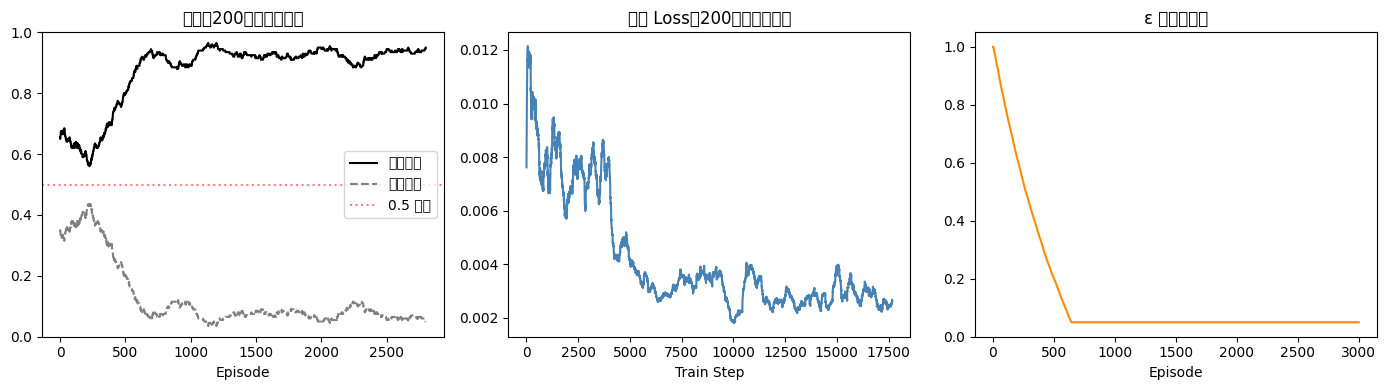

最后 500 局：黑赢=471(94.2%)  白赢=29(5.8%)  平=0(0.0%)


In [15]:
def smooth(data, w=100):
    return np.convolve(data, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 胜率曲线
ax = axes[0]
bw = [1 if w == 1  else 0 for w in win_history]
ww = [1 if w == -1 else 0 for w in win_history]
ax.plot(smooth(bw, 200), label='黑方胜率', color='black')
ax.plot(smooth(ww, 200), label='白方胜率', color='gray', ls='--')
ax.axhline(0.5, color='red', ls=':', alpha=0.5, label='0.5 基准')
ax.set_title('胜率（200局滑动平均）'); ax.set_xlabel('Episode')
ax.legend(); ax.set_ylim(0, 1)

# Loss 曲线
ax = axes[1]
if len(loss_history) > 200:
    ax.plot(smooth(loss_history, 200), color='steelblue')
ax.set_title('训练 Loss（200步滑动均值）'); ax.set_xlabel('Train Step')

# ε 衰减
ax = axes[2]
ax.plot(eps_history, color='darkorange')
ax.set_title('ε 探索率衰减'); ax.set_xlabel('Episode')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# 最后 500 局统计
recent = win_history[-500:]
b, w, d = sum(1 for x in recent if x==1), sum(1 for x in recent if x==-1), sum(1 for x in recent if x==0)
print(f"最后 500 局：黑赢={b}({b/5:.1f}%)  白赢={w}({w/5:.1f}%)  平={d}({d/5:.1f}%)")

## Cell 9：评估——DQN（贪心）vs 随机策略

固定 ε=0（纯贪心），分别以先手/后手对阵随机策略，统计胜率。
**预期**：DQN 综合胜率应显著高于 50%。

**实测结果（修复前加号版本，Q 值已爆炸）：**

```
DQN 先手(黑) vs 随机 500局: 赢=33(6.6%) 平=0 输=467
DQN 后手(白) vs 随机 500局: 赢=17(3.4%) 平=0 输=483
```

胜率 6% 远低于随机策略（50%），说明网络完全没有学到有效策略。

**诊断过程：**

1. 先确认 `agent.steps=52159`，排除了「用了未训练的 agent」的可能
2. 打印单局 Q 值，发现数量级是 `2e10`（约 200 亿）→ 确认 Q 值爆炸
3. 正常训练好的网络 Q 值应在 -1 到 +1 附近（奖励只有 ±1）
4. 追溯到 Bellman 方程用了 `+` 而非 `-`，修复后重新训练

In [16]:
def greedy_action(agent: DQNAgent, board: np.ndarray, player: int, legal: np.ndarray) -> int:
    with torch.no_grad():
        q = agent.online_net(board_to_tensor(board, player).to(DEVICE)).squeeze(0).cpu().numpy()
    return int(legal[np.argmax(q[legal])])


def evaluate_vs_random(agent: DQNAgent, env: GomokuEnv, n: int = 500):
    for dqn_player, label in [(1, '先手(黑)'), (-1, '后手(白)')]:
        wins = draws = losses = 0
        for _ in range(n):
            state = env.reset()
            done  = False
            while not done:
                legal = env.get_legal_actions()
                if env.current_player == dqn_player:
                    action = greedy_action(agent, state, env.current_player, legal)
                else:
                    action = int(np.random.choice(legal))
                state, _, done, info = env.step(action)
            w = info['winner']
            if w == dqn_player:    wins   += 1
            elif w == 0:           draws  += 1
            else:                  losses += 1
        print(f"DQN {label} vs 随机 {n}局: 赢={wins}({wins/n*100:.1f}%) 平={draws} 输={losses}")


print(agent.steps)
evaluate_vs_random(agent, env5)
print("\n（随机基准：胜率约 50%，DQN 应显著高于此）")

17872
DQN 先手(黑) vs 随机 500局: 赢=500(100.0%) 平=0 输=0
DQN 后手(白) vs 随机 500局: 赢=489(97.8%) 平=0 输=11

（随机基准：胜率约 50%，DQN 应显著高于此）


## Cell 10：Q 值热力图——可视化 Agent 的决策

把当前局面每个位置的 Q 值渲染为热力图，直观看 Agent「认为哪里最值得落子」。

**Q 值的范围：**

- **正数**：Agent 认为落这里最终赢的可能性大
- **负数**：Agent 认为落这里最终输的可能性大
- 使用减号版 Bellman 后，Q 值理论范围约在 **-1 到 +1** 附近
- 出现稍微超出范围的值（如 1.2 或 -1.3）是正常的，说明训练还未完全收敛

**demo 棋盘是手动构造的：**

```python
demo = np.zeros((5,5), dtype=np.int8)
demo[2,1] = 1   # 直接赋值，跳过 env.step()
demo[2,2] = 1
demo[0,0] = -1
```

直接写 numpy array，不走环境规则，棋子数量不需要符合真实对局。
`player=1` 只是告诉网络「用黑棋视角输出 Q 值」，不代表真实轮到谁落子。

**实测观察：白棋两连会干扰 Agent 判断**

将 demo 改为黑棋间隔两连 + 白棋两连时，黑棋成三位置 (2,2) 的 Q 值只有 -0.13，
说明 Agent 被白棋的威胁干扰了，没有果断选择必赢点。
将白棋改回一子后 Q 值回升，确认是白棋威胁影响了判断。

根本原因是训练量不足（3000 局），Agent 还没学会「成三必落/堵二必要」的明确策略。

/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1906441457.py:31: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  plt.suptitle(title); plt.tight_layout(); plt.show()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1906441457.py:31: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.suptitle(title); plt.tight_layout(); plt.show()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1906441457.py:31: UserWarning: Glyph 26827 (\N{CJK UNIFIED IDEOGRAPH-68CB}) missing from font(s) DejaVu Sans.
  plt.suptitle(title); plt.tight_layout(); plt.show()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1906441457.py:31: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  plt.suptitle(title); plt.tight_layout(); plt.show()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1906441457.py:31: U

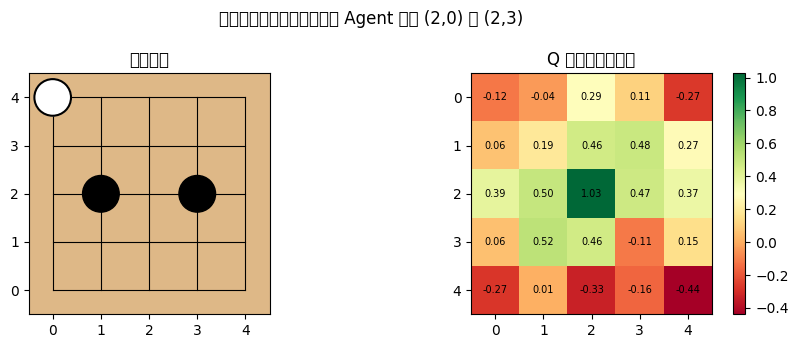

In [20]:
def show_q_heatmap(agent: DQNAgent, board: np.ndarray, player: int, title: str = ""):
    n = board.shape[0]
    with torch.no_grad():
        q = agent.online_net(board_to_tensor(board, player).to(DEVICE)).squeeze(0).cpu().numpy()
    q_map = q.reshape(n, n)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

    # 棋盘
    ax1.set_facecolor('#DEB887')
    for i in range(n):
        ax1.plot([0,n-1],[i,i],'k-',lw=0.8); ax1.plot([i,i],[0,n-1],'k-',lw=0.8)
    for r in range(n):
        for c in range(n):
            if board[r,c] == 1:
                ax1.add_patch(plt.Circle((c,n-1-r),0.38,color='black',zorder=3))
            elif board[r,c] == -1:
                ax1.add_patch(plt.Circle((c,n-1-r),0.38,color='white',zorder=3))
                ax1.add_patch(plt.Circle((c,n-1-r),0.38,color='black',fill=False,lw=1.5,zorder=4))
    ax1.set_xlim(-0.5,n-0.5); ax1.set_ylim(-0.5,n-0.5)
    ax1.set_aspect('equal'); ax1.set_title('当前棋局')

    # 热力图
    im = ax2.imshow(np.flipud(q_map), cmap='RdYlGn', aspect='equal')
    for r in range(n):
        for c in range(n):
            ax2.text(c, n-1-r, f'{q_map[r,c]:.2f}', ha='center', va='center', fontsize=7)
    fig.colorbar(im, ax=ax2)
    ax2.set_title(f'Q 值（{"黑" if player==1 else "白"}方视角）')

    plt.suptitle(title); plt.tight_layout(); plt.show()


# 示例：黑棋横向两连，Agent 是否会选择延伸？
demo = np.zeros((5,5), dtype=np.int8)
# 黑棋两连
demo[2,1] = 1
demo[2,3] = 1
# 白棋一子
demo[0,0] = -1
#demo[0,1] = -1

show_q_heatmap(agent, demo, player=1,
               title="示例：黑棋横向两连，期望 Agent 偏好 (2,0) 或 (2,3)")

## Cell 11：可视化一局对战过程

DQN(黑 X) vs 随机(白 O)
  step 1: DQN(X) 落 (2,1)  reward=0.0
  step 2: 随机(O) 落 (2,4)  reward=0.0
  step 3: DQN(X) 落 (2,2)  reward=0.0
  step 4: 随机(O) 落 (3,2)  reward=0.0
  step 5: DQN(X) 落 (2,0)  reward=1.0


/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1181507461.py:19: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1181507461.py:19: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1181507461.py:19: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1181507461.py:19: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78611/1181507461.py:19: UserWarning: Glyph 36194 (\N{CJK UNIFIED IDEOGRAPH-8D62}) missing from font(s) DejaVu Sans.
  pl

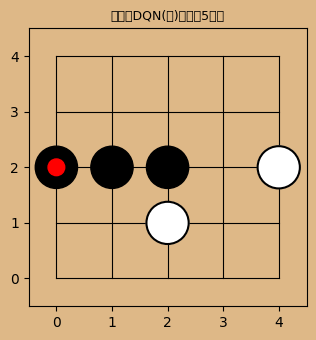

In [21]:
def render_board(board: np.ndarray, title: str = "", last_action: int = None):
    n = board.shape[0]
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    ax.set_facecolor('#DEB887'); fig.patch.set_facecolor('#DEB887')
    for i in range(n):
        ax.plot([0,n-1],[i,i],'k-',lw=0.8); ax.plot([i,i],[0,n-1],'k-',lw=0.8)
    for r in range(n):
        for c in range(n):
            if board[r,c] == 1:
                ax.add_patch(plt.Circle((c,n-1-r),0.38,color='black',zorder=3))
            elif board[r,c] == -1:
                ax.add_patch(plt.Circle((c,n-1-r),0.38,color='white',zorder=3))
                ax.add_patch(plt.Circle((c,n-1-r),0.38,color='black',fill=False,lw=1.5,zorder=4))
    if last_action is not None:
        lr, lc = divmod(last_action, n)
        ax.add_patch(plt.Circle((lc,n-1-lr),0.15,color='red',zorder=5))
    ax.set_xlim(-0.5,n-0.5); ax.set_ylim(-0.5,n-0.5)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=9)
    plt.tight_layout(); plt.show()


# DQN(黑) vs 随机(白) 一局实况
state = env5.reset()
done = False; step_n = 0
print("DQN(黑 X) vs 随机(白 O)")
while not done:
    legal = env5.get_legal_actions()
    if env5.current_player == 1:
        action = greedy_action(agent, state, 1, legal); who = 'DQN(X)'
    else:
        action = int(np.random.choice(legal)); who = '随机(O)'
    state, reward, done, info = env5.step(action)
    step_n += 1
    r, c = divmod(action, 5)
    print(f"  step {step_n}: {who} 落 ({r},{c})  reward={reward:.1f}")

winner_str = {1:'DQN(黑)赢', -1:'随机(白)赢', 0:'平局'}.get(info['winner'],'')
render_board(state, title=f"终局：{winner_str}（共{step_n}步）", last_action=action)

## 小结

### 本 notebook 完成了什么

| 目标 | 状态 |
|---|---|
| DQN Agent（Q 网络 + Replay Buffer + Target Network） | 完成 |
| 自我对弈训练循环 + ε-greedy 探索 | 完成 |
| 训练曲线可视化（胜率 / Loss / ε 衰减） | 完成 |
| DQN vs 随机策略评估 | 完成 |
| Q 值热力图（可解释性） | 完成 |

### 核心 RL 概念对照

| 概念 | 代码体现 |
|---|---|
| Q 值 | `QNetwork` 输出层，N×N 个位置各一个 Q 值 |
| Bellman 方程 | `train_step` 中 `q_target = r - γ·max Q(s',a')`（零和减号） |
| ε-greedy | `select_action` 中随机 vs 贪心 |
| Experience Replay | `ReplayBuffer` 随机采样打破时序相关 |
| Target Network | `target_net` 定期同步，稳定训练目标 |

### 踩过的坑

**Q 值爆炸**：Bellman 方程对双人零和游戏必须用减号。
用加号时对手 Q 值会正反馈累加，loss 从 0.34 炸到 10²¹，
评估胜率只有 6%（比随机还差）。

### 尝试：用中间奖励改善"白棋两连干扰"问题

**问题**：黑棋间隔两连 + 白棋两连的局面中，黑棋必赢位置 (2,2) 的 Q 值只有 -0.13，
Agent 被白棋威胁干扰，没有果断选择必赢点。

**假设**：加入中间奖励（形成两连 +0.3，堵对方两连 +0.2）可以让 Agent 更快学会进攻和防守。

**实验过程**：

1. 在 `env.py` 的 `step()` 中加入 `_intermediate_reward()`，统计落子后最大连子数，分别给进攻/防守奖励
2. 用相同的 3000 局训练，对比问题局面的 Q 值

**实验结果**：

| 模型 | (2,2) Q 值 | 最优落子 |
|---|---|---|
| 无中间奖励（基准） | +0.80 | (1,3)，Q=0.81 |
| 有中间奖励 | +0.18 | (3,3)，Q=0.45 |

中间奖励版反而更差。

**根因分析**：

当前 Bellman 是零和版本：`q_target = r - γ·q_next`，减号的前提是 reward 只有 {-1, 0, +1}，正负对称。
加入中间奖励后，reward 变成 {0, 0.2, 0.3, 0.5, 1.0}，**全是正值，完全破坏了零和对称性**。

诊断数据：
```
稀疏奖励：非零 reward 步骤占  8.4%（只有赢棋）
中间奖励：非零 reward 步骤占 67.3%（绝大多数步骤都有正奖励）
```

自我对弈时双方都在收正奖励，Q 值无法正确反映"我赢 = 你输"，学到的策略反而混乱。

**要正确使用中间奖励，需要做架构改动**：

把 reward 拆成两个字段——终局奖励（零和）和塑形奖励（非零和）——在 Bellman 公式里分别处理：

```python
q_target = r_terminal - γ·q_next*(1-done) + r_shaping
#           ↑ 零和，用减号         ↑ 非零和，直接加
```

这需要改动 `env.py` + `agent.py` + `train.py` 三个文件，
目前 `dqn/env.py` 中的 `_intermediate_reward` 接口已经实现，可作为后续扩展的基础。

### 如果想继续改善 Agent 表现

| 方向 | 做法 | 预期效果 | 复杂度 |
|---|---|---|---|
| 增加训练量 | `num_episodes=20000` | 最简单，直接有效 | 低 |
| 中间奖励（正确版） | 拆分 r_terminal / r_shaping，分别处理 | 效果最显著 | 高（改三个文件） |
| 加深网络 | Conv 层从 2 层加到 3 层，通道数翻倍 | 学习更复杂棋型 | 中 |
| 减慢探索衰减 | `eps_decay=20000` | 增加数据多样性 | 低 |

### 下一步：阶段二 RLVR Tool-Use

| | DQN（阶段一） | GRPO（阶段二） |
|---|---|---|
| Policy | Q 网络（CNN） | LLM（Qwen2.5-1.5B）|
| Action | 棋盘位置整数 | 文本序列（工具调用）|
| Reward | 赢/输/平 | 答案正确性（可验证）|
| 优化 | 最小化 Q 误差（MSE） | 策略梯度（GRPO）|
